# 0: Dataset download

In [141]:
import numpy as np
import cupy as cp
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

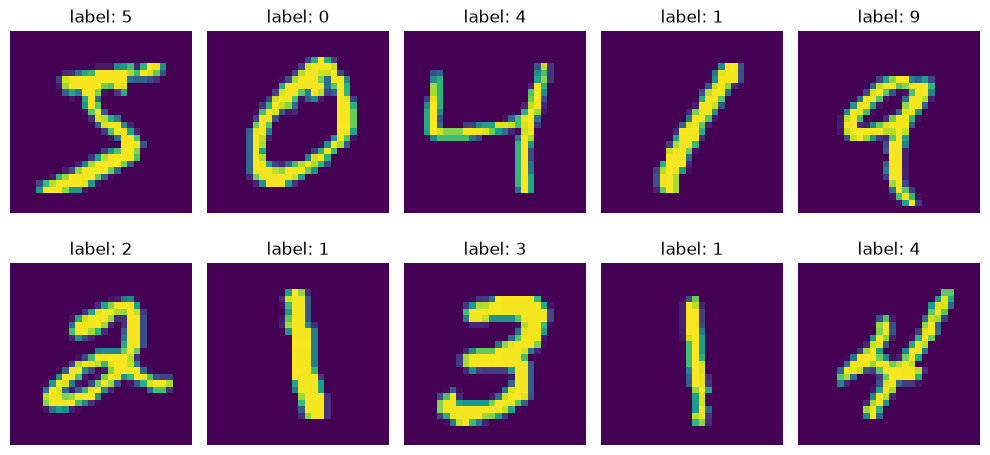

In [142]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X[i].reshape(28, 28))
    ax.set_title(f'label: {y[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 0.5 Data preprocesing

In [143]:
X = cp.asarray(X.T/255)
y_one_hot = cp.zeros((70000, 10))
y = cp.asarray(y, dtype=int)
print(len(y_one_hot))
for i in range(len(y)):
    y_val = int(y[i])
    y_one_hot[i][y_val] = 1
y_one_hot = y_one_hot.T
random_idx = cp.random.permutation(X.shape[1])
X = X[:, random_idx]
y_one_hot = y_one_hot[:, random_idx]
y = y[random_idx]

70000


# 1. Initialize Weight (He initialization)

In [144]:
def initialize_weight(node_num_list):
    parameters = {}
    for l in range(1, len(node_num_list)):
        parameters['W'+str(l)] = cp.random.randn(node_num_list[l], node_num_list[l-1])
        parameters['b'+str(l)] = cp.zeros((node_num_list[l],1))
    return parameters

In [145]:
n = [2, 2, 2, 1]
dic = initialize_weight(n)
print(dic)

{'W1': array([[-1.33057109, -0.78949869],
       [-1.23855573, -1.66240647]]), 'b1': array([[0.],
       [0.]]), 'W2': array([[-0.29770575,  0.55917382],
       [-0.99366141, -0.3602531 ]]), 'b2': array([[0.],
       [0.]]), 'W3': array([[2.96706245, 1.45428309]]), 'b3': array([[0.]])}


## 2. Forward_propagation

In [146]:
def relu(x):
    return cp.maximum(0, x)

def softmax(x):
    x = cp.exp(x)
    sum = cp.sum(x, axis=0)
    return x / sum

def forward_propagation(X, parameters):
    cache = {'A0': X}
    L = len(parameters) // 2
    A_prev = X

    # ReLU
    for l in range(1, L):
        W = parameters['W'+str(l)]
        b = parameters['b'+str(l)]
        Z = W @ A_prev + b
        A = relu(Z)
        A_prev = A

        cache['W'+str(l)] = W
        cache['Z'+str(l)] = Z
        cache['A'+str(l)] = A

    # softmax
    W = parameters['W'+str(L)]
    b = parameters['b'+str(L)]
    Z = W @ A_prev + b
    y_hat = softmax(Z)

    cache['W'+str(L)] = W
    cache['Z'+str(L)] = Z
    cache['A'+str(L)] = y_hat

    return y_hat, cache


In [147]:
params = initialize_weight([784, 10, 10])
print(params['W1'].shape)

(10, 784)


In [148]:
y_hat, cache = forward_propagation(X[:, 0:2], params)
print(y_hat, cp.sum(y_hat))
print(cache.keys())

[[2.25436819e-06 6.73378262e-07]
 [4.22137404e-13 1.47950533e-08]
 [7.72888271e-15 1.13798765e-16]
 [6.69212407e-19 3.53789834e-18]
 [2.79273694e-01 1.14229062e-05]
 [1.46110183e-15 1.07549805e-10]
 [3.74242293e-09 4.49597805e-09]
 [7.20724048e-01 9.99750395e-01]
 [9.53454041e-21 1.58107361e-05]
 [1.63813837e-13 2.21678147e-04]] 2.0
dict_keys(['A0', 'W1', 'Z1', 'A1', 'W2', 'Z2', 'A2'])


## 3. Compute cost

In [149]:
print(y_hat.shape)
print(y_one_hot.shape)

(10, 2)
(10, 70000)


In [150]:
def compute_cost(y_hat, y):
    epsilon = 1e-7
    return cp.mean(-1 * cp.log(cp.sum(y * y_hat, axis=0) + epsilon)).get()

res = compute_cost(y_hat, y_one_hot[:, 0:2])
print(res)

16.077735983207646


## 4. Back propagation

In [151]:
def back_propagation(y_hat, y, parameters, cache):
    grads = {}
    cache = cache
    m = y_hat.shape[1]

    L = len(parameters) // 2
    grads['dZ'+str(L)] = y_hat - y
    grads['dW'+str(L)] = (grads['dZ'+str(L)] @ cache['A'+str(L-1)].T)/m
    grads['db'+str(L)] = cp.mean(grads['dZ'+str(L)], axis=1, keepdims=True)
    grads['dA'+str(L-1)] = cache['W'+str(L)].T @ grads['dZ'+str(L)]

    for l in range(L-1, 0, -1):
        grads['dZ'+str(l)] = grads['dA'+str(l)] * cp.where(cache['Z'+str(l)]>0, 1, 0)
        grads['dW'+str(l)] = (grads['dZ'+str(l)] @ cache['A'+str(l-1)].T)/m
        grads['db'+str(l)] = cp.mean(grads['dZ'+str(l)], axis=1, keepdims=True)
        grads['dA'+str(l-1)] = cache['W'+str(l)].T @ grads['dZ'+str(l)]

    return grads

In [152]:
grads = back_propagation(y_hat, y_one_hot[:, 0:2], params, cache)
print(grads.keys())

dict_keys(['dZ2', 'dW2', 'db2', 'dA1', 'dZ1', 'dW1', 'db1', 'dA0'])


# 5. Parameter update

In [153]:
def update_parameters(learning_rate, parameters, grads):
    L = len(parameters) // 2
    for l in range(1, L+1):
        parameters['W'+str(l)] -= learning_rate * grads['dW'+str(l)]
        parameters['b'+str(l)] -= learning_rate * grads['db'+str(l)]
    return parameters

In [154]:
res = update_parameters(0.001, params, grads)
print(res['W1'].shape)

(10, 784)


# 6. Model

In [155]:
class Model(object):
    def __init__(self, node_num_list):
        self.parameters = initialize_weight(node_num_list)

    def train(self, X_train, y_train, X_val, y_val, learning_rate, epoches, display=False):
        #1. initialize_weight
        train_loss_list = []
        val_loss_list = []

        for epoch in range(epoches):
            #2. forward propagation
            y_hat, cache = forward_propagation(X_train, self.parameters)

            #3. compute cost
            cost = compute_cost(y_hat, y_train)
            train_loss_list.append(cost)

            #4. back propagation
            grads = back_propagation(y_hat, y_train, self.parameters, cache)

            #4.5 val_loss
            y_hat_val, _ = forward_propagation(X_val, self.parameters)
            val_cost = compute_cost(y_hat_val, y_val)
            val_loss_list.append(val_cost)

            #5. update parameters
            self.parameters = update_parameters(learning_rate, self.parameters, grads)
            if epoch % 100 == 0 and display:
                print(f'cost of {epoch}th epoch: {cp.round(cost, 4)}')

        return train_loss_list, val_loss_list

    def predict(self, X):
        y_hat, _ = forward_propagation(X, self.parameters)
        return cp.argmax(y_hat, axis=0)


# 7. Training

In [184]:
X_train = X[:, :3000]
y_train = y_one_hot[:, :3000]

X_val = X[:, 3000:4000]
y_val = y_one_hot[:, 3000:4000]

epoches = 1000
node_num_list = [784, 500, 100, 10]
epoches_list = np.arange(0, epoches)
model = Model(node_num_list)
train_loss_list, val_loss_list = model.train(X_train, y_train, X_val, y_val, 50, epoches, True)

cost of 0th epoch: nan
cost of 100th epoch: nan
cost of 200th epoch: nan
cost of 300th epoch: nan
cost of 400th epoch: nan
cost of 500th epoch: nan
cost of 600th epoch: nan
cost of 700th epoch: nan
cost of 800th epoch: nan
cost of 900th epoch: nan


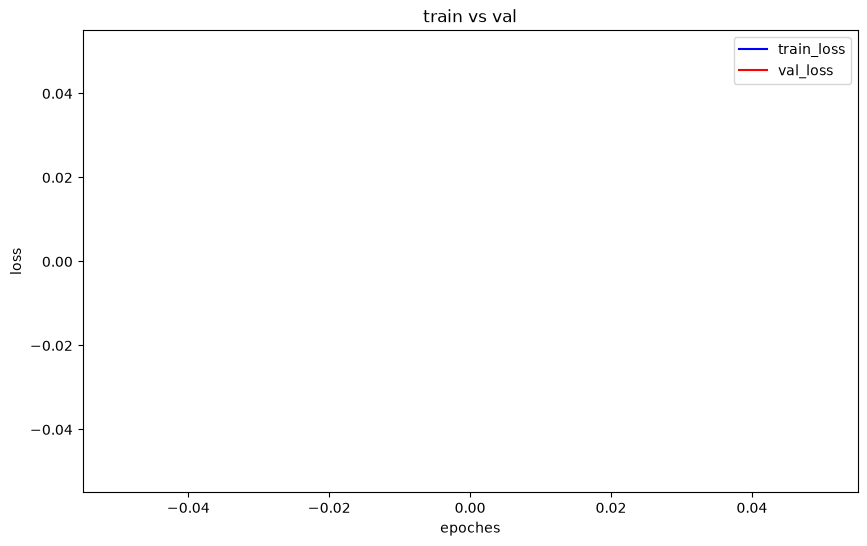

In [186]:
plt.figure(figsize=(10, 6))
plt.plot(epoches_list, train_loss_list, color='blue', label='train_loss')
plt.plot(epoches_list, val_loss_list, color='red', label='val_loss')
plt.xlabel('epoches')
plt.ylabel('loss')
plt.title('train vs val')
plt.legend()
plt.show()

In [187]:
print('train set loss :', np.round(train_loss_list[-1], 3))
print('val set loss :', np.round(val_loss_list[-1], 3))

train set loss : nan
val set loss : nan


# 8. Compute accuracy

In [188]:
y_pred = model.predict(X[:,5000:65000])

In [189]:
cp.mean(y_pred == y[5000:65000])

array(0.09925)

In [208]:
model.parameters['W1']

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(500, 784))